In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    matthews_corrcoef, balanced_accuracy_score,
)

warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
BASE_DIR = r"C:\Users\Ayush\Desktop\mrNet\MRNet_v1"
RESULTS_DIR = r"C:\Users\Ayush\Desktop\mrNet\MRNet_v1\Results\VGG16"

os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid')

LABEL_FILES = {
    'train': {
        'abnormal' : os.path.join(BASE_DIR, 'train-abnormal.csv'),
        'acl'      : os.path.join(BASE_DIR, 'train-acl.csv'),
        'meniscus' : os.path.join(BASE_DIR, 'train-meniscus.csv'),
    },
    'valid': {
        'abnormal' : os.path.join(BASE_DIR, 'valid-abnormal.csv'),
        'acl'      : os.path.join(BASE_DIR, 'valid-acl.csv'),
        'meniscus' : os.path.join(BASE_DIR, 'valid-meniscus.csv'),
    }
}

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("VALID_DIR exists:", os.path.exists(VALID_DIR))

BASE_DIR exists: True
TRAIN_DIR exists: True
VALID_DIR exists: True


In [4]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

VALID_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

In [5]:
class MRNetDataset(Dataset):
    def __init__(self, data_dir, label_files, plane='sagittal', transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.plane = plane

        df_abn = pd.read_csv(label_files['abnormal'], header=None, names=['id', 'abnormal'])
        df_acl = pd.read_csv(label_files['acl'], header=None, names=['id', 'acl'])
        df_men = pd.read_csv(label_files['meniscus'], header=None, names=['id', 'meniscus'])

        df = df_abn.merge(df_acl, on='id').merge(df_men, on='id')
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        case_id = self.df.iloc[idx]['id']
        label = torch.tensor(
            self.df.iloc[idx][['abnormal', 'acl', 'meniscus']].values.astype(float),
            dtype=torch.float32
        )

        vol_path = os.path.join(self.data_dir, self.plane, f'{case_id:04d}.npy')
        volume = np.load(vol_path)

        mid = volume.shape[0] // 2
        slice_ = volume[mid]

        s_min, s_max = slice_.min(), slice_.max()
        if s_max > s_min:
            slice_ = (slice_ - s_min) / (s_max - s_min) * 255.0
        slice_ = slice_.astype(np.uint8)

        img = Image.fromarray(slice_).convert('RGB')
        if self.transform:
            img = self.transform(img)

        return img, label

In [6]:
PLANE = 'sagittal'

train_dataset = MRNetDataset(
    data_dir=TRAIN_DIR,
    label_files=LABEL_FILES['train'],
    plane=PLANE,
    transform=TRAIN_TRANSFORM
)

valid_dataset = MRNetDataset(
    data_dir=VALID_DIR,
    label_files=LABEL_FILES['valid'],
    plane=PLANE,
    transform=VALID_TRANSFORM
)

print("Train dataset size:", len(train_dataset))
print("Valid dataset size:", len(valid_dataset))

Train dataset size: 1130
Valid dataset size: 120


In [7]:
img, label = train_dataset[0]
print("Image shape:", img.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: tensor([1., 0., 0.])


In [8]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("NEW DataLoader created successfully")

NEW DataLoader created successfully


In [9]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8, 3])


In [10]:
NUM_CLASSES = 3   # abnormal | acl | meniscus

def build_vgg16(num_classes=NUM_CLASSES, dropout=0.5):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(4096, num_classes)
        # No Sigmoid here — BCEWithLogitsLoss handles it
    )

    return model

model = build_vgg16().to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nTotal params     : {total:,}')
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {total - trainable:,}')


Total params     : 134,272,835
Trainable params : 119,558,147
Frozen params    : 14,714,688


In [11]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-6
)

In [12]:
import time
import sys

EPOCHS     = 50
THRESHOLD  = 0.5
TASK_NAMES = ['Abnormal', 'ACL', 'Meniscus']

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'lr'        : [],
    # Per-epoch macro metrics
    'train_f1'          : [], 'val_f1'          : [],
    'train_sensitivity' : [], 'val_sensitivity' : [],
    'train_specificity' : [], 'val_specificity' : [],
    'train_mcc'         : [], 'val_mcc'         : [],
    'train_bal_acc'     : [], 'val_bal_acc'     : [],
}


def _compute_extra_metrics(loader, train_mode=True):
    """Run one pass and return (loss, acc, f1, sensitivity, specificity, mcc, bal_acc)."""
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_lbl, all_prd = [], []

    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            if train_mode:
                optimizer.zero_grad()

            logits = model(images)
            loss   = criterion(logits, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs >= THRESHOLD).float()
            correct += (preds == labels).all(dim=1).sum().item()
            total   += images.size(0)

            all_lbl.append(labels.cpu().numpy())
            all_prd.append(preds.cpu().numpy())

            if batch_idx % 20 == 0:
                print(f"   {'Train' if train_mode else 'Valid'} Batch [{batch_idx+1}/{len(loader)}]",
                      flush=True)

    all_lbl = np.vstack(all_lbl)   # (N, 3)
    all_prd = np.vstack(all_prd)   # (N, 3)

    epoch_loss = total_loss / total
    epoch_acc  = correct / total

    # Macro-averaged across tasks
    f1   = f1_score(all_lbl, all_prd, average='macro', zero_division=0)
    sens = recall_score(all_lbl, all_prd, average='macro', zero_division=0)  # sensitivity = recall

    spec_list, mcc_list, ba_list = [], [], []
    for t in range(all_lbl.shape[1]):
        tn, fp, fn, tp = confusion_matrix(all_lbl[:, t], all_prd[:, t], labels=[0,1]).ravel()
        spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        mcc_list.append(matthews_corrcoef(all_lbl[:, t], all_prd[:, t]))
        ba_list.append(balanced_accuracy_score(all_lbl[:, t], all_prd[:, t]))

    spec   = float(np.mean(spec_list))
    mcc    = float(np.mean(mcc_list))
    bal_acc= float(np.mean(ba_list))

    return epoch_loss, epoch_acc, f1, sens, spec, mcc, bal_acc


best_val_loss = float('inf')
best_state    = None

print('\n' + '='*75)
print('  Starting VGG16 Training — 50 Epochs')
print('='*75, flush=True)

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    print(f"\n🔹 Starting Epoch {epoch}/{EPOCHS}...", flush=True)

    tr_loss, tr_acc, tr_f1, tr_sens, tr_spec, tr_mcc, tr_ba = \
        _compute_extra_metrics(train_loader, train_mode=True)
    vl_loss, vl_acc, vl_f1, vl_sens, vl_spec, vl_mcc, vl_ba = \
        _compute_extra_metrics(valid_loader, train_mode=False)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['train_sensitivity'].append(tr_sens)
    history['val_sensitivity'].append(vl_sens)
    history['train_specificity'].append(tr_spec)
    history['val_specificity'].append(vl_spec)
    history['train_mcc'].append(tr_mcc)
    history['val_mcc'].append(vl_mcc)
    history['train_bal_acc'].append(tr_ba)
    history['val_bal_acc'].append(vl_ba)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    epoch_time = time.time() - start_time
    print(f'✅ Epoch [{epoch:02d}/{EPOCHS}]  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}  '
          f'Train F1: {tr_f1:.4f}  Val F1: {vl_f1:.4f}  '
          f'LR: {current_lr:.2e}  Time: {epoch_time:.1f}s', flush=True)

print('\nTraining complete!', flush=True)
torch.save(best_state, os.path.join(RESULTS_DIR, 'vgg16_best.pth'))
print(f'Best checkpoint saved → best val loss = {best_val_loss:.4f}', flush=True)


  Starting VGG16 Training — 50 Epochs

🔹 Starting Epoch 1/50...
   Train Batch [1/142]
   Train Batch [21/142]
   Train Batch [41/142]
   Train Batch [61/142]
   Train Batch [81/142]
   Train Batch [101/142]
   Train Batch [121/142]
   Train Batch [141/142]
   Valid Batch [1/15]
✅ Epoch [01/50]  Train Loss: 0.5388  Train Acc: 0.3938  Val Loss: 0.5384  Val Acc: 0.3500  Train F1: 0.4590  Val F1: 0.6274  LR: 9.99e-05  Time: 851.9s

🔹 Starting Epoch 2/50...
   Train Batch [1/142]
   Train Batch [21/142]
   Train Batch [41/142]
   Train Batch [61/142]
   Train Batch [81/142]
   Train Batch [101/142]
   Train Batch [121/142]
   Train Batch [141/142]
   Valid Batch [1/15]
✅ Epoch [02/50]  Train Loss: 0.4573  Train Acc: 0.4469  Val Loss: 0.7377  Val Acc: 0.2417  Train F1: 0.5715  Val F1: 0.4266  LR: 9.96e-05  Time: 807.7s

🔹 Starting Epoch 3/50...
   Train Batch [1/142]
   Train Batch [21/142]
   Train Batch [41/142]
   Train Batch [61/142]
   Train Batch [81/142]
   Train Batch [101/142]
   

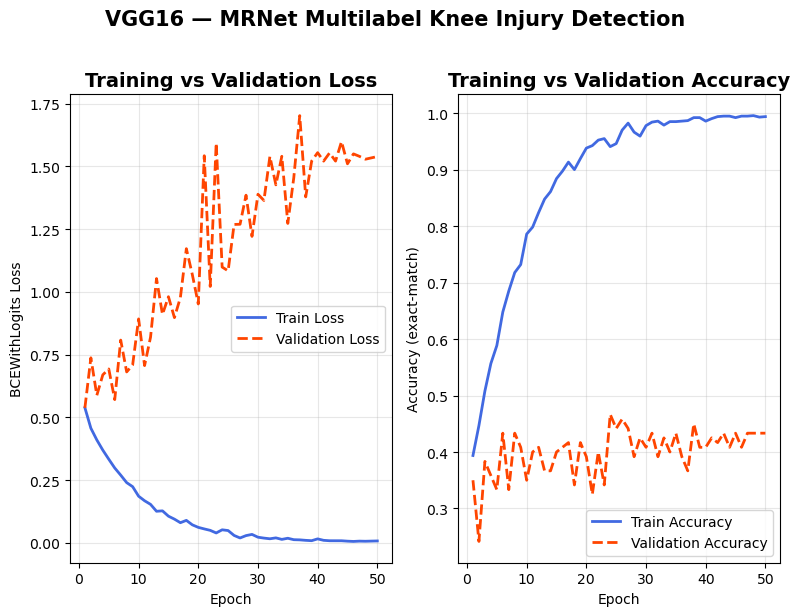

Saved: loss_accuracy_curves.png


In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss',
             color='royalblue', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Validation Loss',
             color='orangered', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCEWithLogits Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy',
             color='royalblue', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   label='Validation Accuracy',
             color='orangered', linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (exact-match)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('VGG16 — MRNet Multilabel Knee Injury Detection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_accuracy_curves.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: loss_accuracy_curves.png')

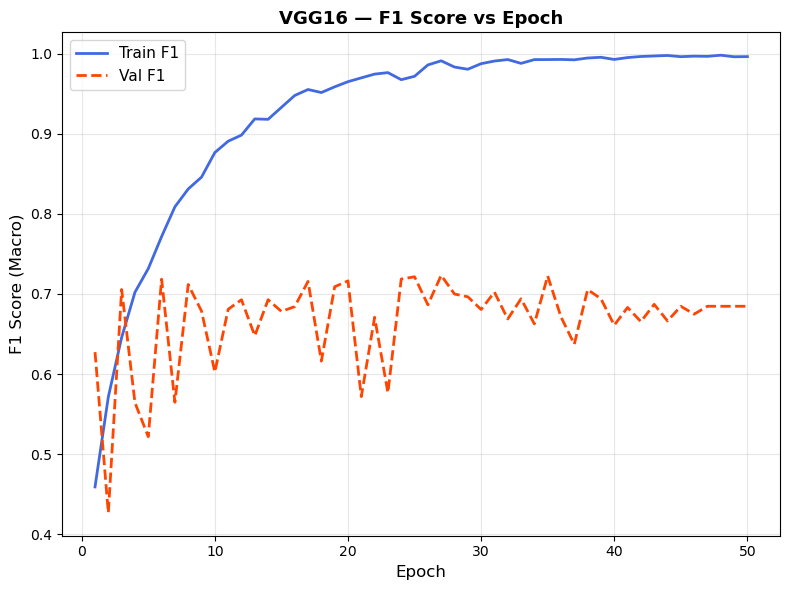

Saved: curve_f1.png


In [14]:
# ── F1 Score Curve ────────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(epochs_range, history['train_f1'], lw=2, color='royalblue', label='Train F1')
ax.plot(epochs_range, history['val_f1'],   lw=2, color='orangered', linestyle='--', label='Val F1')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('F1 Score (Macro)', fontsize=12)
ax.set_title('VGG16 — F1 Score vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curve_f1.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: curve_f1.png')

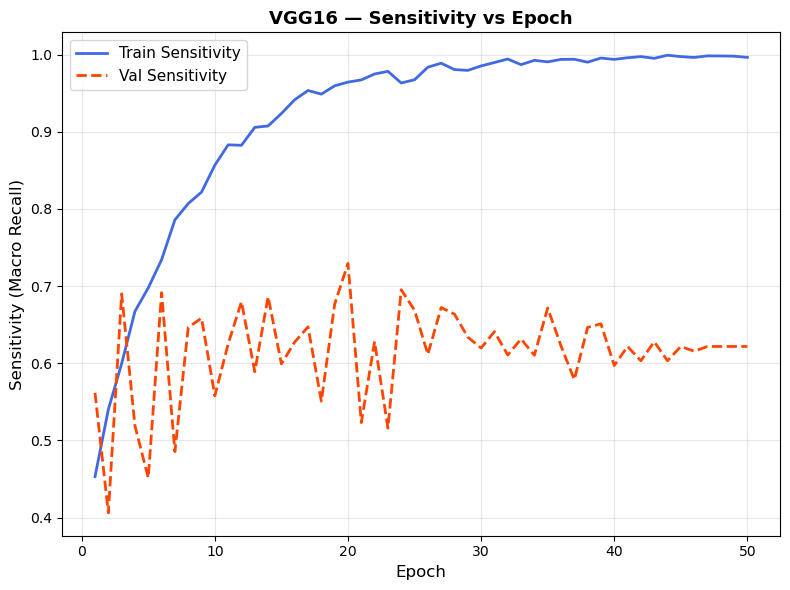

Saved: curve_sensitivity.png


In [15]:
# ── Sensitivity (Recall) Curve ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(epochs_range, history['train_sensitivity'], lw=2, color='royalblue', label='Train Sensitivity')
ax.plot(epochs_range, history['val_sensitivity'],   lw=2, color='orangered', linestyle='--', label='Val Sensitivity')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Sensitivity (Macro Recall)', fontsize=12)
ax.set_title('VGG16 — Sensitivity vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curve_sensitivity.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: curve_sensitivity.png')

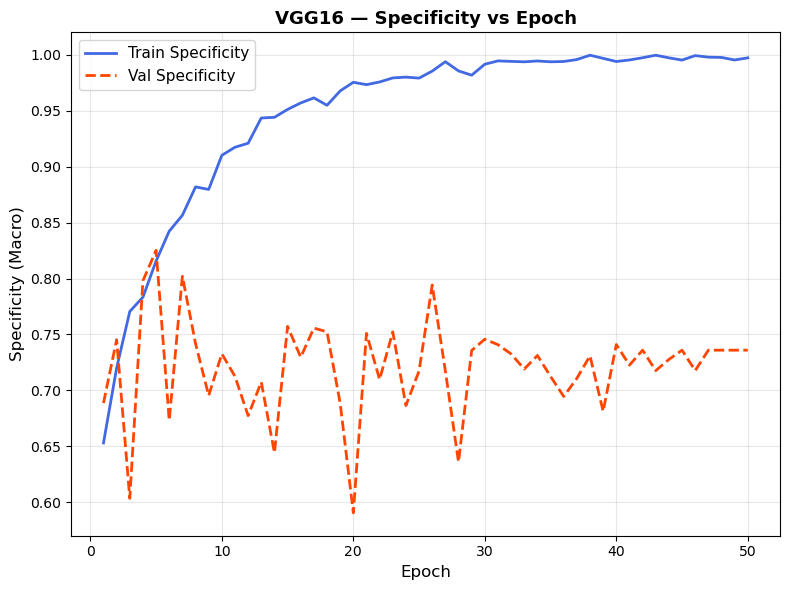

Saved: curve_specificity.png


In [16]:
# ── Specificity Curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(epochs_range, history['train_specificity'], lw=2, color='royalblue', label='Train Specificity')
ax.plot(epochs_range, history['val_specificity'],   lw=2, color='orangered', linestyle='--', label='Val Specificity')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Specificity (Macro)', fontsize=12)
ax.set_title('VGG16 — Specificity vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curve_specificity.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: curve_specificity.png')

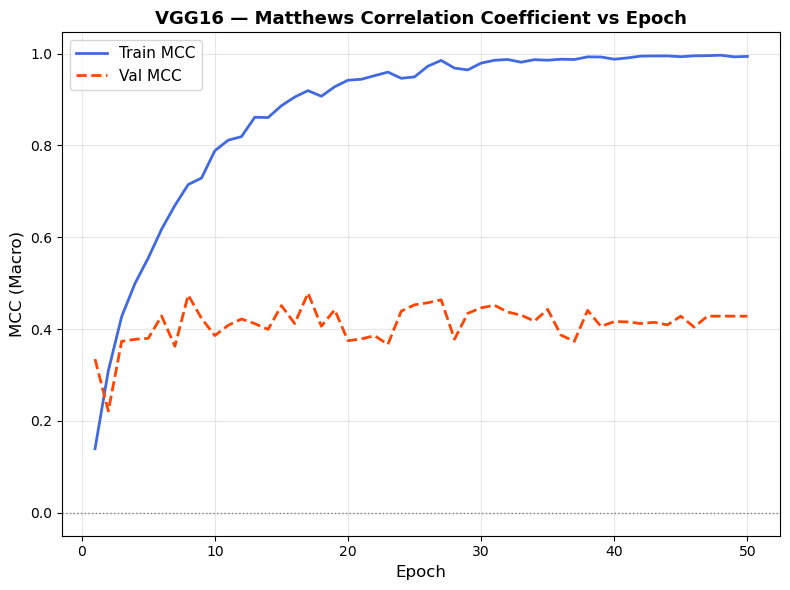

Saved: curve_mcc.png


In [17]:
# ── MCC Curve ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(epochs_range, history['train_mcc'], lw=2, color='royalblue', label='Train MCC')
ax.plot(epochs_range, history['val_mcc'],   lw=2, color='orangered', linestyle='--', label='Val MCC')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MCC (Macro)', fontsize=12)
ax.set_title('VGG16 — Matthews Correlation Coefficient vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=1, linestyle=':')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curve_mcc.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: curve_mcc.png')

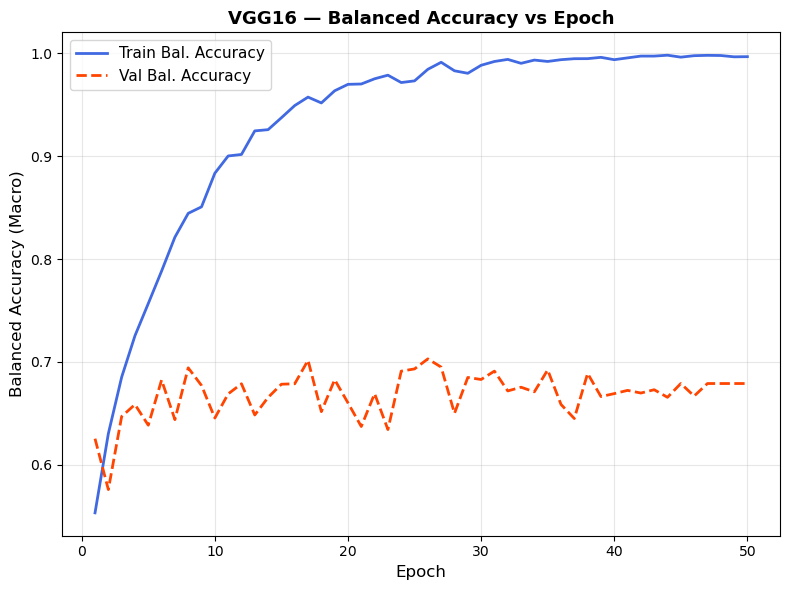

Saved: curve_balanced_accuracy.png


In [18]:
# ── Balanced Accuracy Curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(epochs_range, history['train_bal_acc'], lw=2, color='royalblue', label='Train Bal. Accuracy')
ax.plot(epochs_range, history['val_bal_acc'],   lw=2, color='orangered', linestyle='--', label='Val Bal. Accuracy')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Balanced Accuracy (Macro)', fontsize=12)
ax.set_title('VGG16 — Balanced Accuracy vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curve_balanced_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: curve_balanced_accuracy.png')

In [19]:
model.load_state_dict(best_state)
model.to(device)
model.eval()

all_labels = []
all_probs  = []
all_preds  = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= THRESHOLD).astype(int)

        all_labels.append(labels.numpy())
        all_probs.append(probs)
        all_preds.append(preds)

all_labels = np.vstack(all_labels)   # (N, 3)
all_probs  = np.vstack(all_probs)    # (N, 3)
all_preds  = np.vstack(all_preds)    # (N, 3)

print(f'\nEvaluation complete  |  Samples: {len(all_labels)}')


Evaluation complete  |  Samples: 120


In [21]:
import seaborn as sns

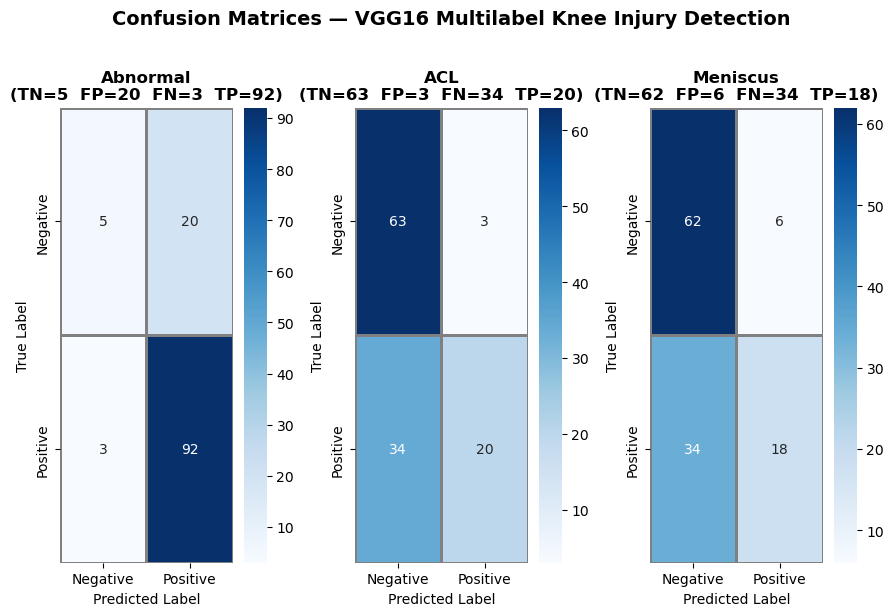

Saved: confusion_matrices.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(9,6))

for i, (task, ax) in enumerate(zip(TASK_NAMES, axes)):
    y_true = all_labels[:, i].astype(int)
    y_pred = all_preds[:, i].astype(int)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                linewidths=1, linecolor='gray')

    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0, 0], 0, 0, 0)
    ax.set_title(f'{task}\n(TN={tn}  FP={fp}  FN={fn}  TP={tp})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — VGG16 Multilabel Knee Injury Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

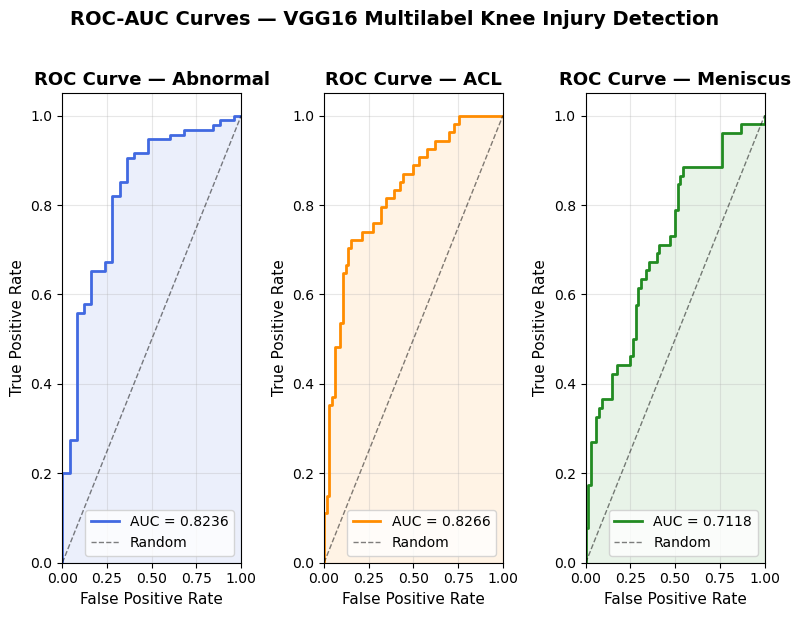

Saved: roc_auc_curves.png


In [23]:
colors = ['royalblue', 'darkorange', 'forestgreen']

fig, axes = plt.subplots(1, 3, figsize=(8, 6))

for i, (task, ax, color) in enumerate(zip(TASK_NAMES, axes, colors)):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]

    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'Single class\nin validation',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(task)
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve — {task}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC-AUC Curves — VGG16 Multilabel Knee Injury Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_auc_curves.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: roc_auc_curves.png')

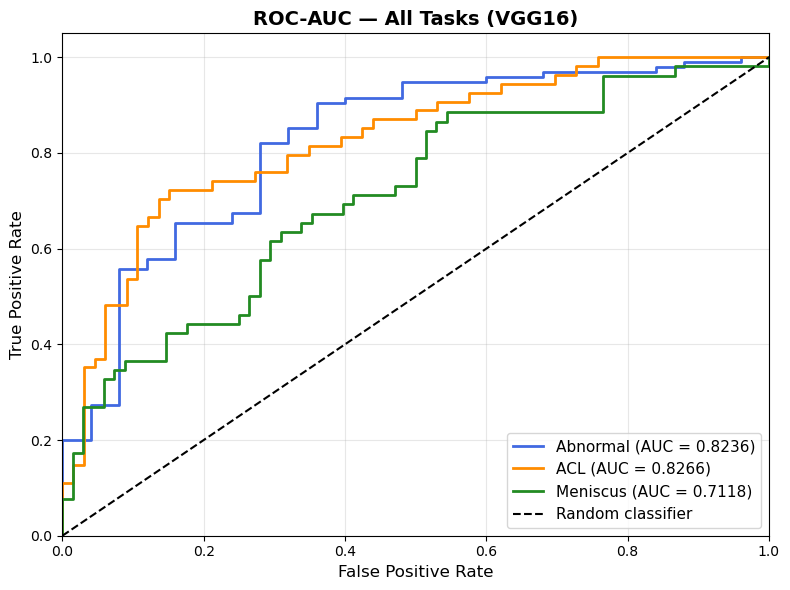

Saved: roc_auc_combined.png


In [24]:
plt.figure(figsize=(8, 6))

for i, (task, color) in enumerate(zip(TASK_NAMES, colors)):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{task} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC — All Tasks (VGG16)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_auc_combined.png'), dpi=300)
plt.show()
print('Saved: roc_auc_combined.png')

In [25]:
results = {}
for i, task in enumerate(TASK_NAMES):
    y_true = all_labels[:, i]
    y_pred = all_preds[:, i]
    y_prob = all_probs[:, i]

    results[task] = {
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'F1 Score'  : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan'),
    }

results['Macro Avg'] = {
    'Precision' : precision_score(all_labels, all_preds, average='macro', zero_division=0),
    'Recall'    : recall_score(all_labels, all_preds, average='macro', zero_division=0),
    'F1 Score'  : f1_score(all_labels, all_preds, average='macro', zero_division=0),
    'ROC-AUC'   : roc_auc_score(all_labels, all_probs, average='macro'),
}

df_results = pd.DataFrame(results).T.round(4)

print('\n===  Per-class & Macro Metrics  ===')
print(df_results.to_string())

df_results.to_csv(os.path.join(RESULTS_DIR, 'vgg16_metrics.csv'))
print('Saved: vgg16_metrics.csv')


===  Per-class & Macro Metrics  ===
           Precision  Recall  F1 Score  ROC-AUC
Abnormal      0.8214  0.9684    0.8889   0.8236
ACL           0.8696  0.3704    0.5195   0.8266
Meniscus      0.7500  0.3462    0.4737   0.7118
Macro Avg     0.8137  0.5616    0.6274   0.7873
Saved: vgg16_metrics.csv


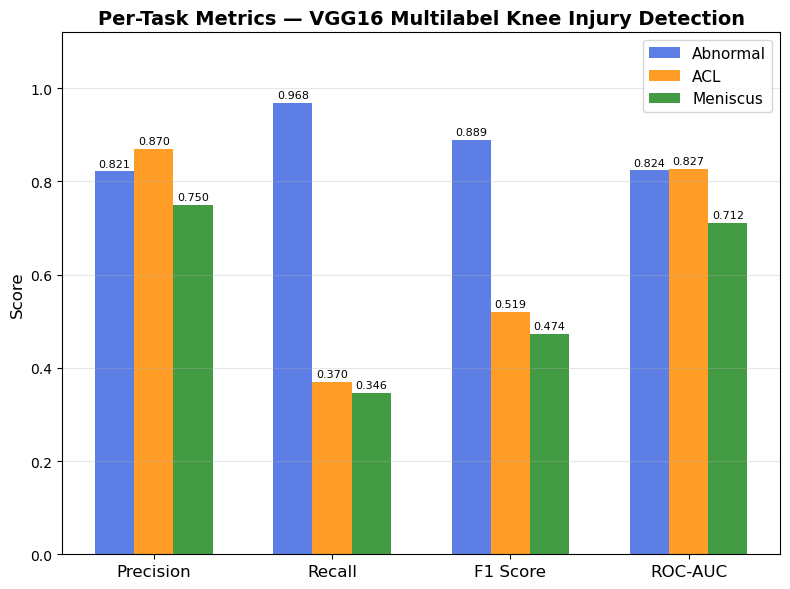

Saved: metrics_bar_chart.png


In [26]:
metrics_to_plot = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
tasks_only      = [t for t in results if t != 'Macro Avg']

x     = np.arange(len(metrics_to_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(8, 6))

for idx, (task, color) in enumerate(zip(tasks_only, colors)):
    vals = [results[task][m] for m in metrics_to_plot]
    bars = ax.bar(x + idx * width, vals, width,
                  label=task, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Task Metrics — VGG16 Multilabel Knee Injury Detection',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_bar_chart.png'), dpi=300)
plt.show()
print('Saved: metrics_bar_chart.png')

In [27]:
for i, task in enumerate(TASK_NAMES):
    print(f'\n{"="*55}')
    print(f'  Classification Report — {task}')
    print(f'{"="*55}')
    print(classification_report(
        all_labels[:, i], all_preds[:, i],
        target_names=['Negative', 'Positive']
    ))


  Classification Report — Abnormal
              precision    recall  f1-score   support

    Negative       0.62      0.20      0.30        25
    Positive       0.82      0.97      0.89        95

    accuracy                           0.81       120
   macro avg       0.72      0.58      0.60       120
weighted avg       0.78      0.81      0.77       120


  Classification Report — ACL
              precision    recall  f1-score   support

    Negative       0.65      0.95      0.77        66
    Positive       0.87      0.37      0.52        54

    accuracy                           0.69       120
   macro avg       0.76      0.66      0.65       120
weighted avg       0.75      0.69      0.66       120


  Classification Report — Meniscus
              precision    recall  f1-score   support

    Negative       0.65      0.91      0.76        68
    Positive       0.75      0.35      0.47        52

    accuracy                           0.67       120
   macro avg       0.70  

In [28]:
df_history = pd.DataFrame({
    'Epoch'          : list(range(1, EPOCHS + 1)),
    'Train Loss'     : history['train_loss'],
    'Val Loss'       : history['val_loss'],
    'Train Accuracy' : history['train_acc'],
    'Val Accuracy'   : history['val_acc'],
    'Learning Rate'  : history['lr'],
})
csv_path = os.path.join(RESULTS_DIR, 'vgg16_training_history.csv')
df_history.to_csv(csv_path, index=False)
print(f'\nTraining history saved → {csv_path}')


Training history saved → C:\Users\Ayush\Desktop\mrNet\MRNet_v1\Results\VGG16\vgg16_training_history.csv


In [29]:
print('\n' + '='*60)
print('    VGG16 Multilabel Knee Injury Detection — Summary')
print('='*60)
print(f'  Epochs trained   : {EPOCHS}')
print(f'  Early stopping   : No')
print(f'  Best val loss    : {best_val_loss:.4f}')
print(f'  Final train loss : {history["train_loss"][-1]:.4f}')
print(f'  Final val loss   : {history["val_loss"][-1]:.4f}')
print(f'  Final train acc  : {history["train_acc"][-1]:.4f}')
print(f'  Final val acc    : {history["val_acc"][-1]:.4f}')
print()
print(df_results.to_string())
print('='*60)


    VGG16 Multilabel Knee Injury Detection — Summary
  Epochs trained   : 50
  Early stopping   : No
  Best val loss    : 0.5384
  Final train loss : 0.0081
  Final val loss   : 1.5396
  Final train acc  : 0.9938
  Final val acc    : 0.4333

           Precision  Recall  F1 Score  ROC-AUC
Abnormal      0.8214  0.9684    0.8889   0.8236
ACL           0.8696  0.3704    0.5195   0.8266
Meniscus      0.7500  0.3462    0.4737   0.7118
Macro Avg     0.8137  0.5616    0.6274   0.7873
